In [24]:
#Load and split the MNIST dataset
from sklearn.datasets import fetch_openml
from tensorflow.keras.datasets import mnist

# Load MNIST dataset from Keras
(X_train_all, y_train_all), (X_test, y_test) = mnist.load_data()
X, y = X_train_all, y_train_all

X_train_all, X_test = X[:1000], X[600:]
y_train_all, y_test = y[:1000], y[600:]



In [25]:
X_train = X_train_all[:1000]
X_validation = X_train_all[1000:2000]
y_train = y_train_all[:1000]
y_validation = y_train_all[1000:2000]

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_validation.shape}, {y_validation.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (1000, 28, 28), (1000,)
Validation set shape: (0, 28, 28), (0,)
Test set shape: (59400, 28, 28), (59400,)


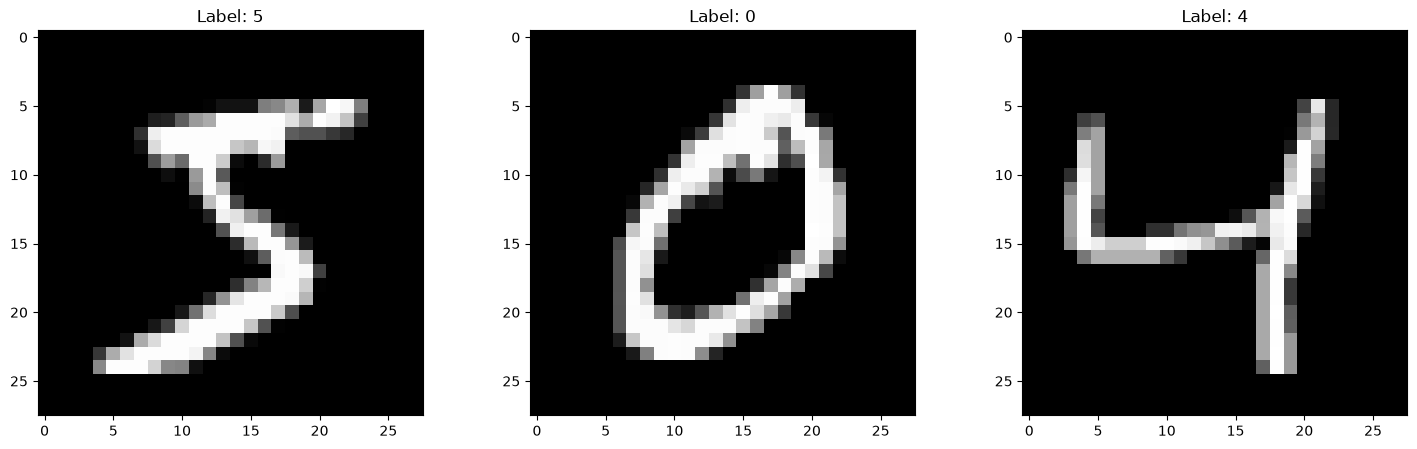

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
for i in range(3):
  plt.subplot(1, 3, i + 1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis(True)
plt.show()

In [27]:
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_train = X_train.astype('float32') / 255.0

X_test = X_test.reshape(X_test.shape[0], 28 * 28)
X_test = X_test.astype('float32') / 255.0

X_validation = X_validation.reshape(X_validation.shape[0], 28 * 28)
X_validation = X_validation.astype('float32') / 255.0

In [28]:
# load the Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist

(X_train_all, y_train_all), (X_test, y_test) = fashion_mnist.load_data()

# The labels in the fashion MNIST dataset are integers from 0 to 9, representing different clothing categories. We can map these integers to their corresponding class names for better understanding.
print(y_train_all[0:9])  # Print the first 10 labels

[9 0 0 3 0 2 7 2 5]


In [29]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train_all, num_classes=10)
print(y_train_onehot[0:9])  # Print the first 10 one-hot encoded labels

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [30]:
# convert the labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_validation = to_categorical(y_validation, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


In [31]:
import tensorflow as tf
# instantiate the model
model = tf.keras.Sequential()

#build the model architecture
model.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(784,))) 
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))  # output layer with 10 classes

# display summary of the model architecture
model.summary()

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
# train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_validation, y_validation))

Epoch 1/10


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4930 - loss: 1.8821
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7840 - loss: 0.9143 
Epoch 3/10
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7969 - loss: 0.7535

c:\Users\markn\.conda\envs\deep_learning\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8670 - loss: 0.5042 
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9060 - loss: 0.3541 
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9330 - loss: 0.2730 
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9560 - loss: 0.2174 
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9620 - loss: 0.1759 
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9740 - loss: 0.1420 
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9840 - loss: 0.1077 
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9910 - loss: 0.0900 


In [34]:
def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):
  
  fig, ax = plt.subplots(figsize=(10, 5))
  
  if not (isinstance(metrics, list) or isinstance(metrics, tuple)):
    metrics = [metrics]
    metric_name = [metric_name] if metric_name else ['Metric']
  for idx, metric in enumerate(metrics):
    ax.plot(metric, label=metric_name[idx] if metric_name else f'Metric {idx+1}', color=color[idx] if color else None)
    
  ax.set_title(title)
  plt.figure(figsize=(10, 5))
  plt.plot(metrics, color=color)
  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel(ylabel)
  if ylim:
      plt.ylim(ylim)
  plt.grid()
  plt.show()

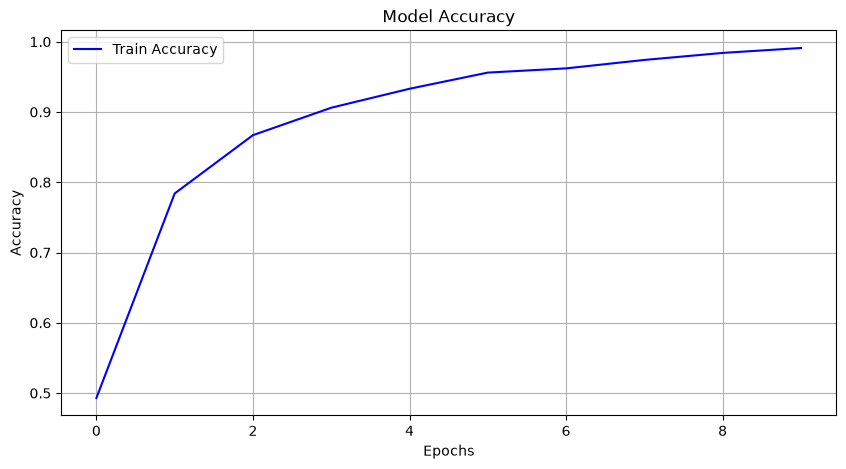

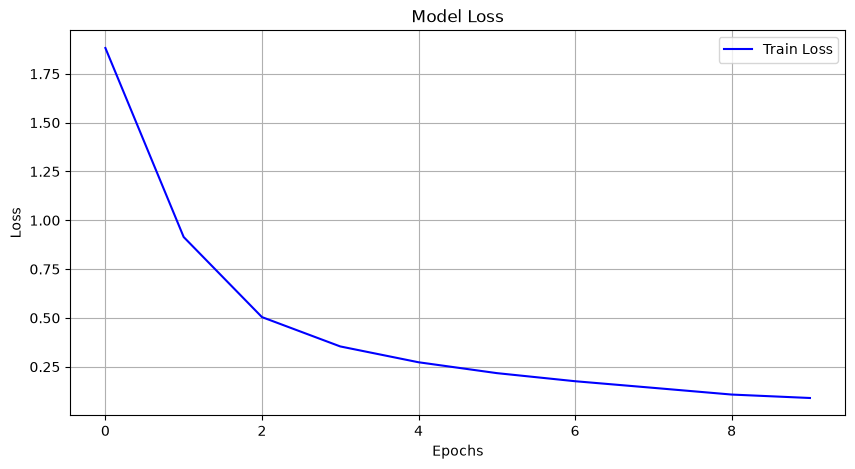

In [35]:
# retrieve the training and validation accuracy from the history object
train_accuracy = history.history.get('accuracy', history.history.get('acc', []))

# safely get validation accuracy (handle cases where validation was not run)
validation_accuracy = history.history.get('val_accuracy', history.history.get('val_acc', []))

train_loss = history.history.get('loss', [])
validation_loss = history.history.get('val_loss', [])

# plot accuracy (skip validation if not available)
if validation_accuracy:
  plot_results([train_accuracy, validation_accuracy], title='Model Accuracy', ylabel='Accuracy', metric_name=['Train Accuracy', 'Validation Accuracy'], color=['blue', 'orange'])
else:
  plt.figure(figsize=(10, 5))
  plt.plot(train_accuracy, color='blue', label='Train Accuracy')
  plt.title('Model Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.grid(True)
  plt.legend()
  plt.show()

# plot loss (skip validation if not available)
if validation_loss:
  plot_results([train_loss, validation_loss], title='Model Loss', ylabel='Loss', metric_name=['Train Loss', 'Validation Loss'], color=['blue', 'orange'])
else:
  plt.figure(figsize=(10, 5))
  plt.plot(train_loss, color='blue', label='Train Loss')
  plt.title('Model Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.grid(True)
  plt.legend()
  plt.show()

validation_accuracy is empty — plotting training accuracy only.


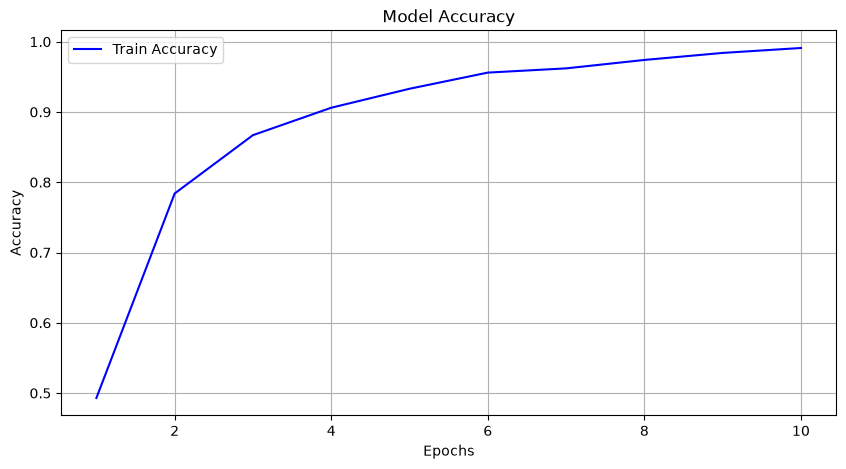

validation_loss is empty — plotting training loss only.


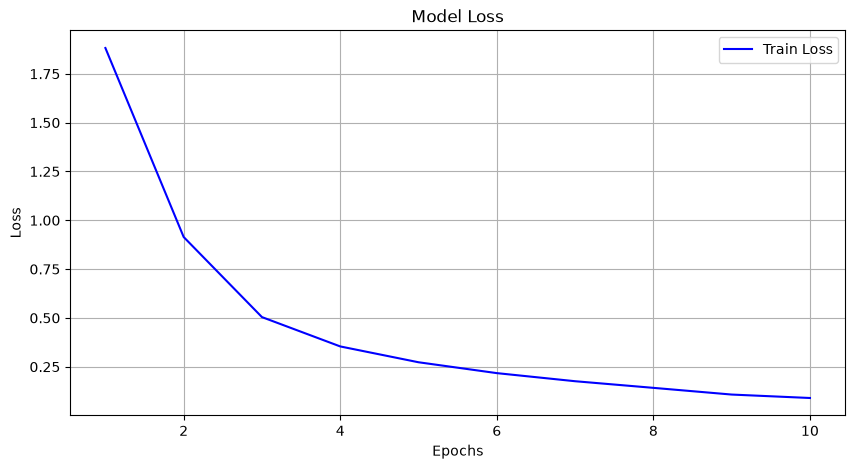

In [36]:
# Plot training and validation accuracy and loss (uses existing variables)
epochs = range(1, len(train_accuracy) + 1)

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, color='blue', label='Train Accuracy')
if validation_accuracy:
  plt.plot(epochs[:len(validation_accuracy)], validation_accuracy, color='orange', label='Validation Accuracy')
else:
  print("validation_accuracy is empty — plotting training accuracy only.")
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, color='blue', label='Train Loss')
if validation_loss:
  plt.plot(epochs[:len(validation_loss)], validation_loss, color='orange', label='Validation Loss')
else:
  print("validation_loss is empty — plotting training loss only.")
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [38]:
# make predictions on the test set
X_test_input = X_test.reshape(X_test.shape[0], 28 * 28).astype("float32") / 255.0

predictions = model.predict(X_test_input)
predicted_labels = tf.argmax(predictions, axis=1).numpy()
true_labels = tf.argmax(y_test, axis=1).numpy()

print("Predicted labels:", predicted_labels[:10])
print("True labels:", true_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted labels: [2 2 6 6 2 2 2 2 4 4]
True labels: [9 2 1 1 6 1 4 6 5 7]


In [39]:
for i in range(10):
  print(f"Digit: {i}, Predicted: {predicted_labels[i]}, True: {true_labels[i]}")

Digit: 0, Predicted: 2, True: 9
Digit: 1, Predicted: 2, True: 2
Digit: 2, Predicted: 6, True: 1
Digit: 3, Predicted: 6, True: 1
Digit: 4, Predicted: 2, True: 6
Digit: 5, Predicted: 2, True: 1
Digit: 6, Predicted: 2, True: 4
Digit: 7, Predicted: 2, True: 6
Digit: 8, Predicted: 4, True: 5
Digit: 9, Predicted: 4, True: 7


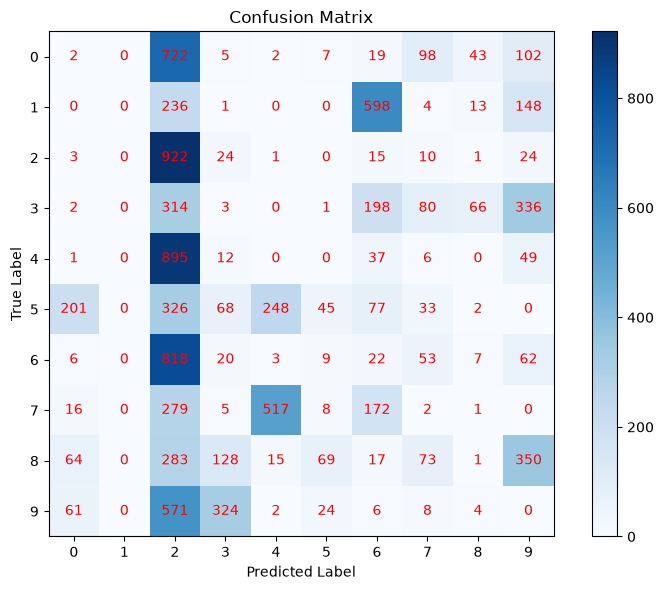

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()

tick_marks = range(10)
plt.xticks(tick_marks)
plt.yticks(tick_marks)

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

plt.tight_layout()
plt.show()